### Jona Nakai

### DS 4420

### Homework #4

In [206]:
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd

## Part 1(a)

In [207]:
AAPL = yf.Ticker("AAPL")
AAPL_values = AAPL.history(start="2025-02-20")[['Close']]
AAPL_values = AAPL_values['Close']

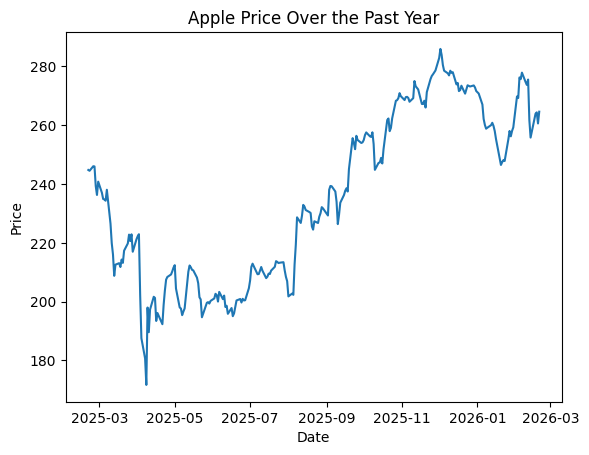

In [208]:
plt.plot(AAPL_values.index, AAPL_values)
plt.title("Apple Price Over the Past Year")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Based on the above graph, the data seems to trend up for the most part, except for the first few months. Without having at least a few years of data, it is hard to tell whether there are seasonal trends. But based on how stocks often work, I doubt there is a seasonal trend. I think a time series approach to this problem is somewhat valid, as the stock tends to generally trend upwards independent of other factors.

## Part 1(b)

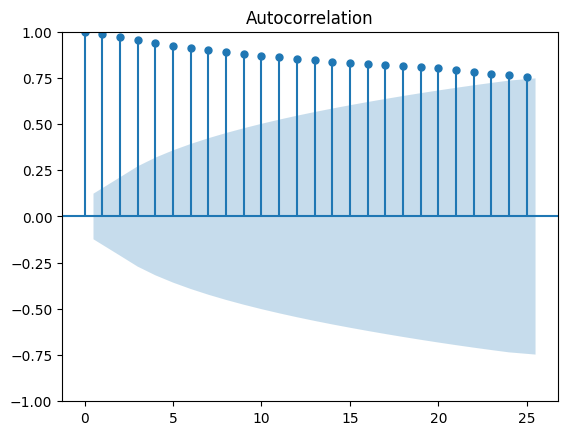

In [209]:
plot_acf(AAPL_values)
plt.show()

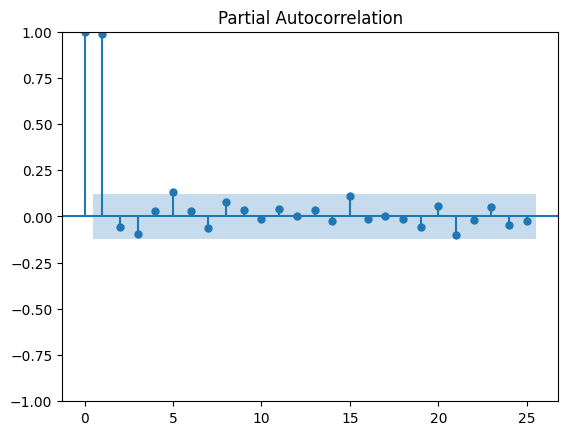

In [210]:
plot_pacf(AAPL_values)
plt.show()

From the graphs above, we can see that ACF trends down over time, and PACF has a sharp drop at around lag 1. This would suggest an AR(1) model would be best for this data.

## Part 2(a)

In [211]:
train_size = int(0.8 * len(AAPL_values))
train_data = AAPL_values[:train_size]
test_data = AAPL_values[train_size:]

In [212]:
p = 1

ar_model = AutoReg(train_data, lags=p, trend='n')
ar_results = ar_model.fit()

print(ar_results.summary())
print(np.abs(ar_results.roots))

                            AutoReg Model Results                             
Dep. Variable:                  Close   No. Observations:                  201
Model:                     AutoReg(1)   Log Likelihood                -583.397
Method:               Conditional MLE   S.D. of innovations              4.473
Date:                Sat, 21 Feb 2026   AIC                           1170.793
Time:                        15:54:28   BIC                           1177.390
Sample:                             1   HQIC                          1173.463
                                  201                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Close.L1       1.0007      0.001    724.079      0.000       0.998       1.003
                                    Roots                                    
                  Real          Imaginary           M

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


The stationary assumption is barely violated. a root of 0.99934 is barely less than 1.

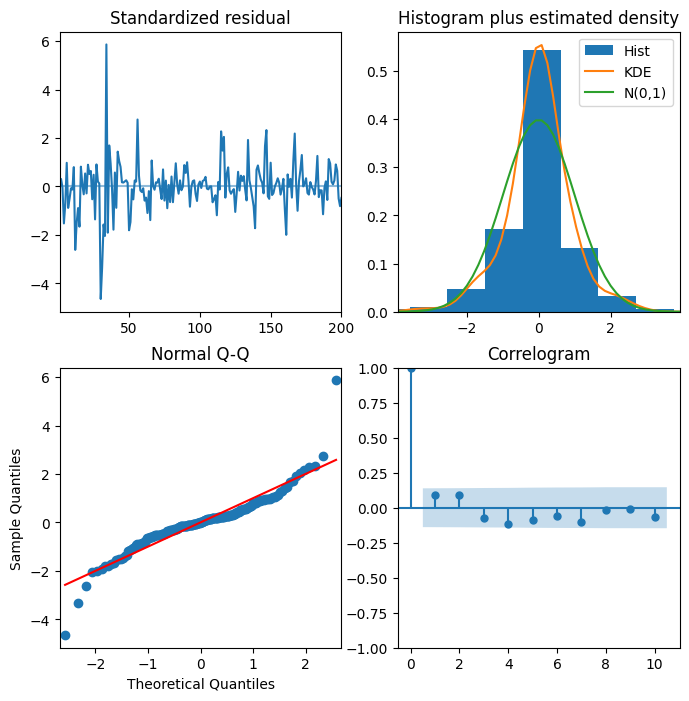

In [213]:
ar_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Looks good, residuals fluctuate around 0

Histogram plus estimated density: Looks good, bell shaped curve around 0, no skew

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Looks good, lag 0 is 1, the rest flucuate around 0 with no patterns

Lag 1's coefficient being greater than 1 indicates a steady upward trend in the stock price. 

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


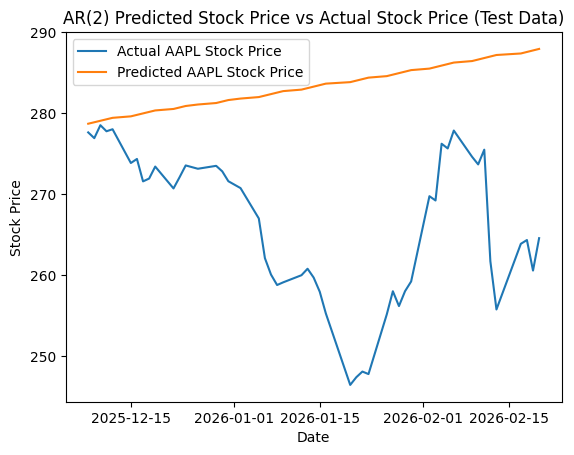

In [214]:
ar_pred = ar_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

plt.plot(test_data.index, test_data, label='Actual AAPL Stock Price')
plt.plot(test_data.index, ar_pred, label='Predicted AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('AR(2) Predicted Stock Price vs Actual Stock Price (Test Data)')
plt.legend()
plt.show()

In [215]:
ar_mae = mean_absolute_error(test_data, ar_pred)
ar_rmse = np.sqrt(mean_squared_error(test_data, ar_pred))

print("MAE:", ar_mae)
print("RMSE:", ar_rmse)

MAE: 17.153259068834615
RMSE: 20.094912520055594


## Part 2(b)

In [238]:
q = 1

ma_model = ARIMA(train_data, order=(0, 0, q))
ma_results = ma_model.fit()

print(ma_results.summary())
print(np.abs(ma_results.maroots))

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  201
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -828.922
Date:                Sat, 21 Feb 2026   AIC                           1663.844
Time:                        17:11:15   BIC                           1673.754
Sample:                             0   HQIC                          1667.854
                                - 201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        227.7661      2.197    103.661      0.000     223.460     232.073
ma.L1          0.8829      0.039     22.808      0.000       0.807       0.959
sigma2       221.9769     28.766      7.717      0.0

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertibl

root is >1 so stationary assumption is met

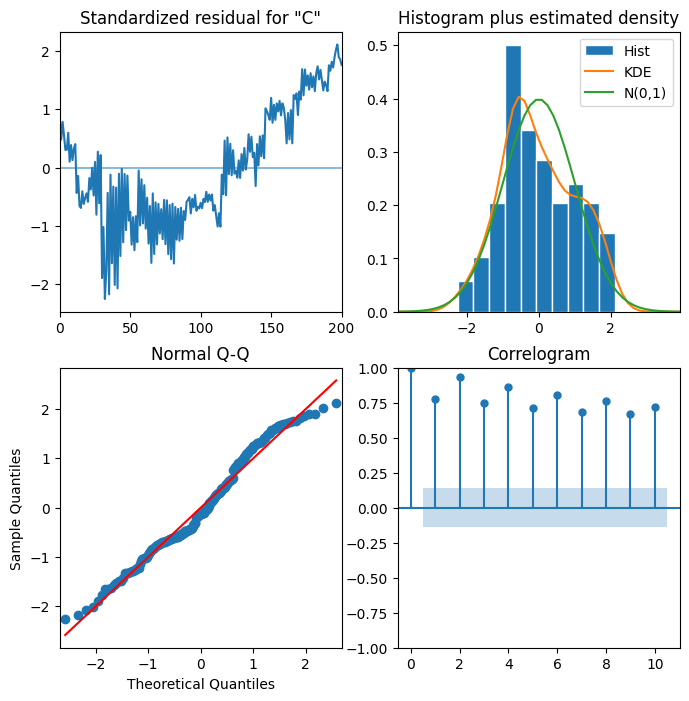

In [239]:
ma_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Not good, not fluctuating around 0, trends down then up

Histogram plus estimated density: Not good, left skewed

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Not good, lags after 0 are not near 0

first coefficient (const) indicates the average for the stock price from the model is around 227.7661. ma.l1 of 0.8829 indicates a large positive shock from the previous term. sigma2 of 221 is the vairance of the noise.

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


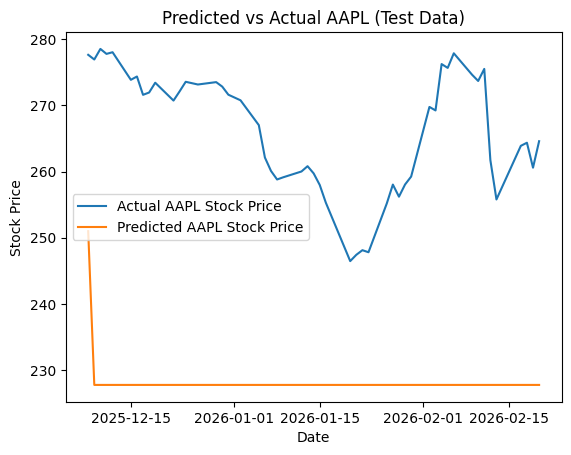

In [240]:
ma_pred = ma_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

plt.plot(test_data.index, test_data, label='Actual AAPL Stock Price')
plt.plot(test_data.index, ma_pred, label='Predicted AAPL Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Predicted vs Actual AAPL (Test Data)')
plt.legend()
plt.show()

In [241]:
ma_mae = mean_absolute_error(test_data, ma_pred)
ma_rmse = np.sqrt(mean_squared_error(test_data, ma_pred))

print("MAE:", ma_mae)
print("RMSE:", ma_rmse)

MAE: 37.916930104697464
RMSE: 38.98997372154394


## Part 2(c)

In [220]:
p, d, q = 2, 1, 1

arima_model = ARIMA(train_data, order=(p, d, q), trend='n')
arima_results = arima_model.fit()

print(arima_results.summary())
print("abs(AR roots):", np.abs(arima_results.arroots))
print("abs(MA roots):", np.abs(arima_results.maroots))

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('N

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  201
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -581.631
Date:                Sat, 21 Feb 2026   AIC                           1171.263
Time:                        15:54:28   BIC                           1184.456
Sample:                             0   HQIC                          1176.602
                                - 201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2277      0.535     -0.425      0.670      -1.276       0.821
ar.L2          0.1243      0.077      1.623      0.105      -0.026       0.274
ma.L1          0.3137      0.538      0.583      0.5

roots are >1 so stationary assumption is met

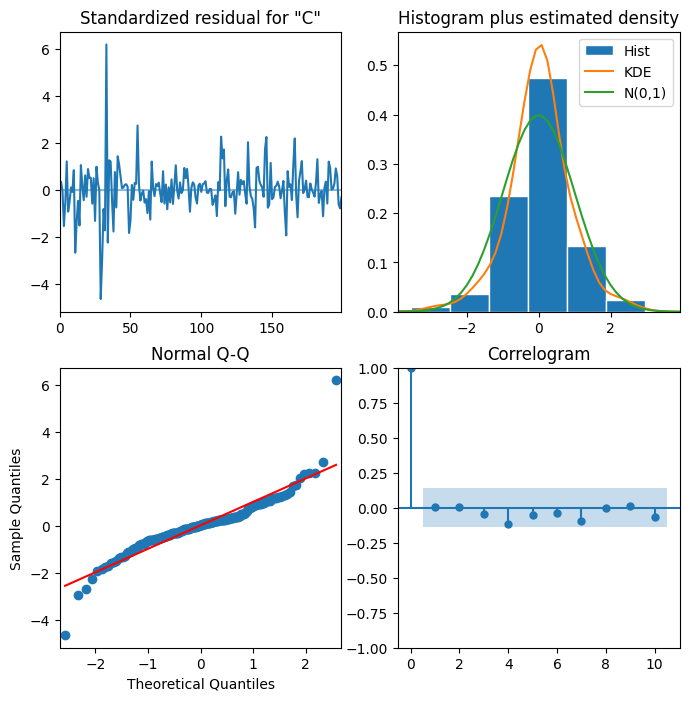

In [221]:
arima_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Looks good, values flucuate around 0

Histogram plus estimated density: Looks good, bell curve no large skew

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Looks good, lags after 0 are around 0

Since all the p values are above 0.05, the lag coefficients may be bad predictors, claims made from the coefficients should be done cautiously.

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


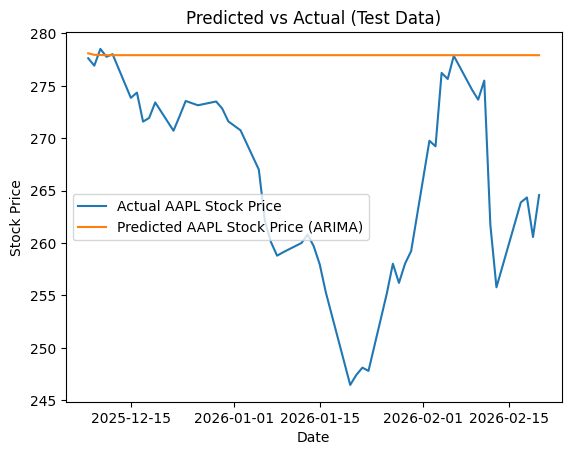

In [222]:
arima_pred = arima_results.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1)

plt.plot(test_data.index, test_data, label='Actual AAPL Stock Price')
plt.plot(test_data.index, arima_pred, label='Predicted AAPL Stock Price (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Predicted vs Actual (Test Data)')
plt.legend()
plt.show()

In [223]:
arima_mae = mean_absolute_error(test_data, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test_data, arima_pred))

print("MAE:", arima_mae)
print("RMSE:", arima_rmse)

MAE: 11.814856256032106
RMSE: 14.882305105449882


## Part 2(d)

Out of AR and MA, it is clear that AR does a better job of prediciting Apple's stock price, but it is still not great. ARIMA out of the 3 models did the best visually, based on the graphs of the prediction vs the test data, and had the lowest MAE and RMSE. Therefore I conclude that ARIMA was the best model to predict the data. The difficulty of predicting Apple's stock price implies that the stock data is complex and hard to predict, at least just based on these simple time series. I don't think the models are worth using. The most accurate model, the ARIMA model, did not have strong lag coefficients. I believe adding more external factors such as other market data, shifts in supply and demand, and other factors would help the model.

## Part 3(b)

In [224]:
music_data = pd.read_csv("music_trends.csv")
music_data["Time"] = pd.to_datetime(music_data["Time"], format="%Y-%m-%d")
music_data = music_data.sort_values("Time")
music_data.set_index("Time", inplace=True)
music = music_data["music"]
music.head()

Time
2004-01-01    86
2004-02-01    86
2004-03-01    86
2004-04-01    89
2004-05-01    85
Name: music, dtype: int64

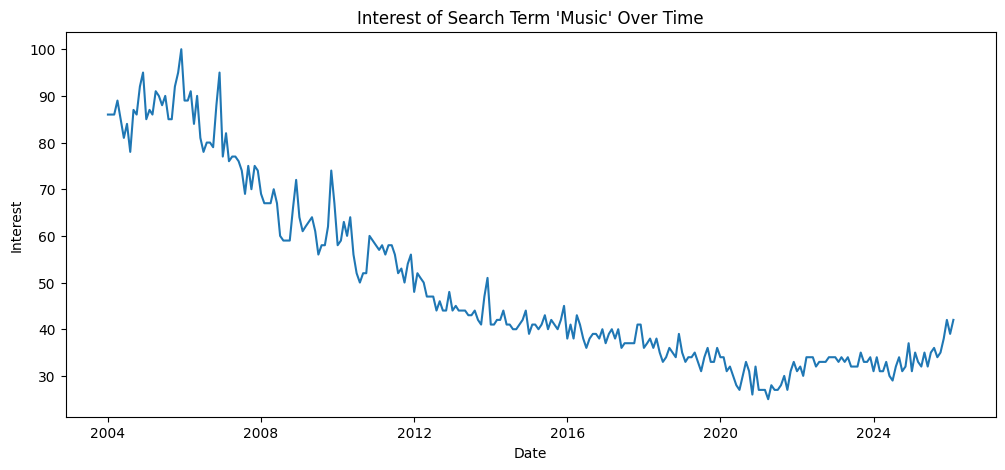

In [225]:
plt.figure(figsize=(12,5))
plt.plot(music)
plt.xlabel('Date')
plt.ylabel('Interest')
plt.title("Interest of Search Term 'Music' Over Time")
plt.show()

I see a trend going downward over time, but interest seeming to flatten after around 2020 and having a slight upward trend in popularity afterwards. I don't see any strong seasonal trends.

## Part 3(c)

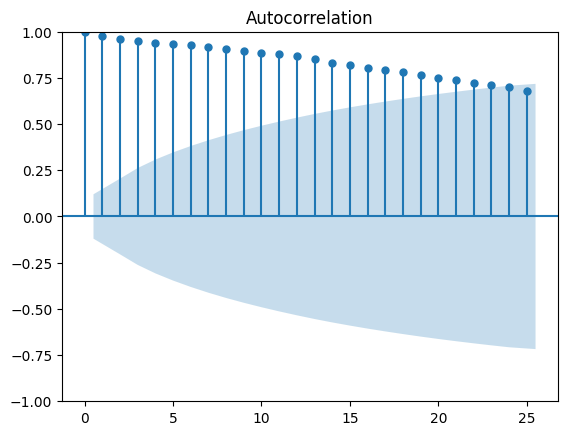

In [226]:
plot_acf(music)
plt.show()

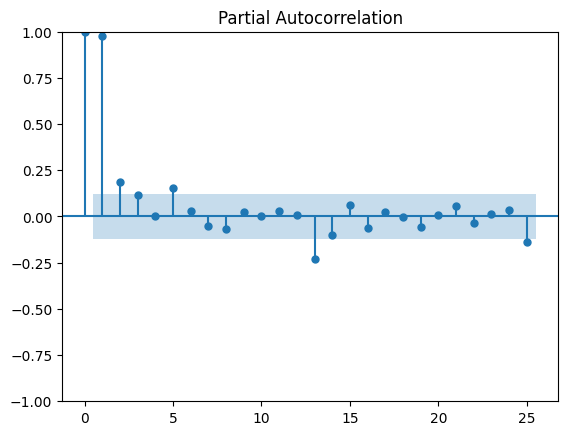

In [227]:
plot_pacf(music)
plt.show()

ACF slowly trends down without any sharp cutoffs. PACF has a sharp cutoff after lag 1. This suggests an AR(1) model would be better suited for this time series data.

## Part 4(a)

In [228]:
train_size = int(0.9 * len(music))
train_music = music[:train_size]
test_music = music[train_size:]

### Fitting AR(1) Model

In [229]:
p = 1

ar_music = AutoReg(train_music, lags=p, trend='n')
ar_music_results = ar_music.fit()

print(ar_music_results.summary())
print(np.abs(ar_music_results.roots))

                            AutoReg Model Results                             
Dep. Variable:                  music   No. Observations:                  239
Model:                     AutoReg(1)   Log Likelihood                -644.682
Method:               Conditional MLE   S.D. of innovations              3.632
Date:                Sat, 21 Feb 2026   AIC                           1293.365
Time:                        15:54:28   BIC                           1300.309
Sample:                    02-01-2004   HQIC                          1296.164
                         - 11-01-2023                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
music.L1       0.9934      0.004    231.802      0.000       0.985       1.002
                                    Roots                                    
                  Real          Imaginary           M

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


The stationary assumption is not violated. a root of 1.0066 is barely greater than 1.

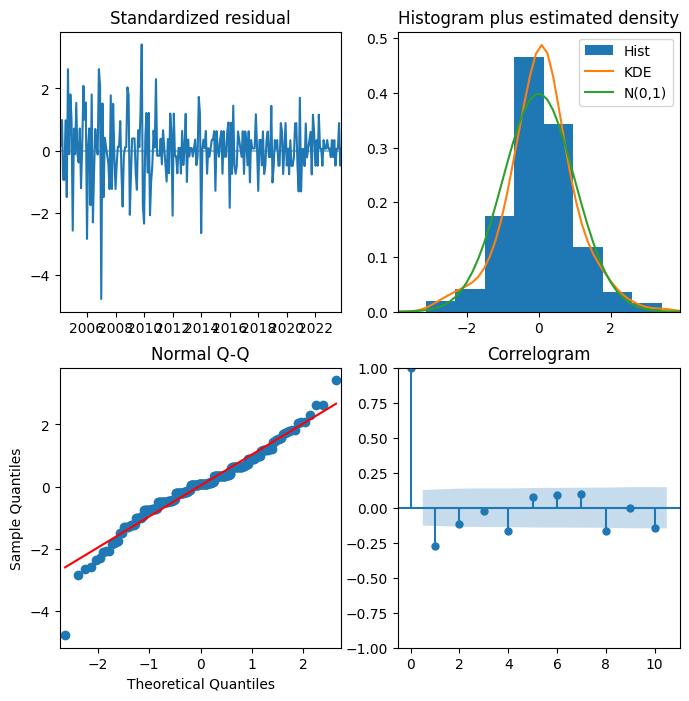

In [230]:
ar_music_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Looks good, residuals fluctuate around 0

Histogram plus estimated density: Looks good, bell shaped curve around 0, no skew

Normal Q-Q: Looks good, points mostly lie on and near the line

Correlogram: Looks good, lag 0 is 1, the rest flucuate around 0 with no patterns

Lag 1's coefficient being less than 1 indicates a very small downward trend.

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


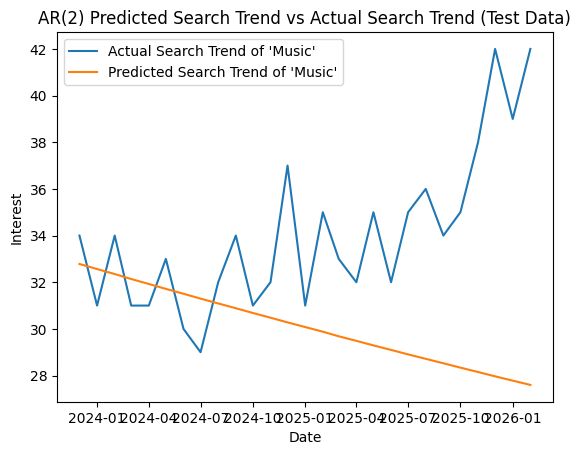

In [231]:
ar_music_pred = ar_music_results.predict(start=len(train_music), end=len(train_music) + len(test_music) - 1)

plt.plot(test_music.index, test_music, label="Actual Search Trend of 'Music'")
plt.plot(test_music.index, ar_music_pred, label="Predicted Search Trend of 'Music'")
plt.xlabel('Date')
plt.ylabel('Interest')
plt.title('AR(2) Predicted Search Trend vs Actual Search Trend (Test Data)')
plt.legend()
plt.show()

In [232]:
ar_music_mae = mean_absolute_error(test_music, ar_music_pred)
ar_music_rmse = np.sqrt(mean_squared_error(test_music, ar_music_pred))

print("MAE:", ar_music_mae)
print("RMSE:", ar_music_rmse)

MAE: 4.431378050520069
RMSE: 5.941161120971941


Based on the MAE and RMSE, the model does farily well, but visually analyzing the prediction on the test data shows that the model does poorly.

### Fitting MA(1) Model

In [233]:
q = 1

ma_music_model = ARIMA(train_music, order=(0, 0, q))
ma_music_results = ma_music_model.fit()

print(ma_music_results.summary())
print(np.abs(ma_music_results.maroots))

                               SARIMAX Results                                
Dep. Variable:                  music   No. Observations:                  239
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -916.315
Date:                Sat, 21 Feb 2026   AIC                           1838.629
Time:                        15:54:29   BIC                           1849.058
Sample:                    01-01-2004   HQIC                          1842.832
                         - 11-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         51.2746      1.747     29.349      0.000      47.850      54.699
ma.L1          0.8905      0.039     22.902      0.000       0.814       0.967
sigma2       124.3902     15.875      7.836      0.0

/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/ds/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


The stationary assumption is not violated. a root of 1.12 is greater than 1.

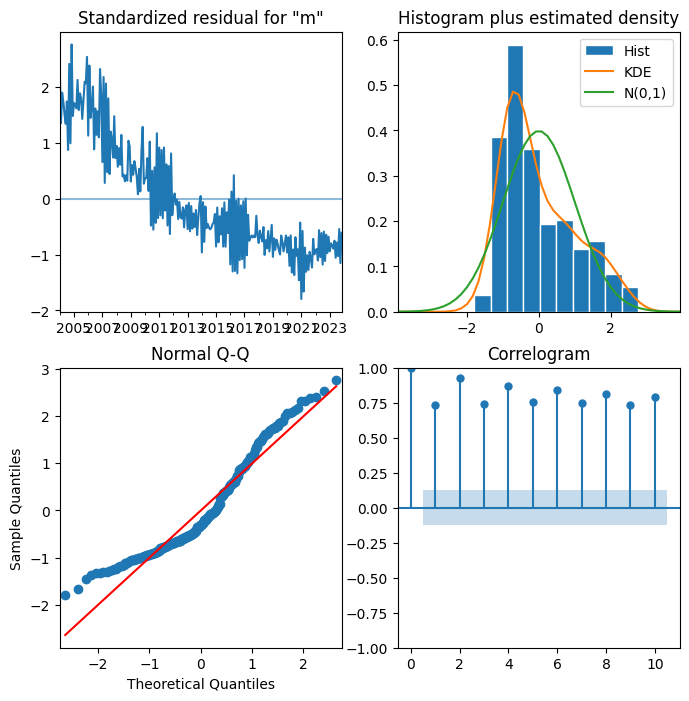

In [234]:
ma_music_results.plot_diagnostics(figsize=(8,8))
plt.show()

Standardized residuals: Not good, not fluctuating around 0, trends downwards

Histogram plus estimated density: Not good, right skewed

Normal Q-Q: Not great, it doesn't follow the line very well

Correlogram: Not good, lags after 0 are not near 0

first coefficient (const) indicates the average for the trend level from the model is around 51.27. ma.l1 of 0.8905 indicates a large positive shock from the previous term. sigma2 of 124 is the vairance of the noise.

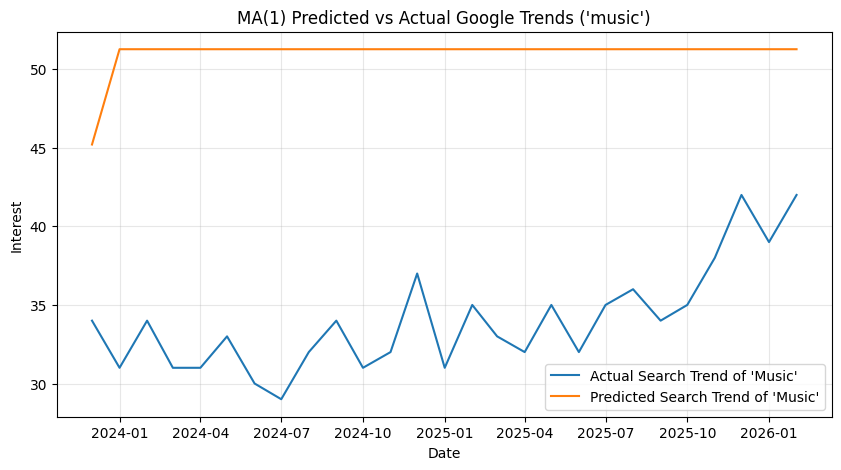

In [235]:
ma_music_pred = ma_music_results.predict(start=len(train_music), end=len(train_music) + len(test_music) - 1)

plt.figure(figsize=(10,5))
plt.plot(test_music.index, test_music, label="Actual Search Trend of 'Music'")
plt.plot(test_music.index, ma_music_pred, label="Predicted Search Trend of 'Music'")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.title("MA(1) Predicted vs Actual Google Trends ('music')")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [236]:
ma_music_mae = mean_absolute_error(test_music, ma_music_pred)
ma_music_rmse = np.sqrt(mean_squared_error(test_music, ma_music_pred))

print("MAE:", ma_music_mae)
print("RMSE:", ma_music_rmse)

MAE: 17.049950439250086
RMSE: 17.399806929225196


Based on the MAE, RMSE, and visually analyzing the graph, the MA model does very poorly at predicting the test data.

## Part 4(b)

I would choose the AR(1) model, even though its performance is not strong. Even though by visually analyzing the test performance, it doesn't seem to follow the trend, I believe the test data was an outlier compared to the general trend of the time series data (which is trending down, accurately reflected in the model). This implies that the data follows trends, instead of being roughly stationary around a level. I think the model is not worth using. As we can see by the prediction of the test data, at a micro level the model does not perform well. If I were to change it, I would potentially try out an ARIMA(1, 1, 1) model, or add external data to help with performance.

## Part 5

I think a very interesting application to auto regression would be to analyze fantasy football performance of NFL football players.

Here is a link to the data set: https://www.fantasypros.com/nfl/reports/leaders/ppr.php?year=2025

By analyzing the statistics of, lets say, the past 1-3 years of how a player performs, we can ask the question of how well they are expected to do this year. I think time series would be an interesting approach to this problem as we can capture upward or downward trends of how a player performs. For example, in a rookie season many players struggle. In year 2, they might start to pick up. In year 3, it is very common for players to really get used to the NFL and "breakout".

An ethical concern would be for sports gambling. If these models are taken too seriously, it can give people the confidence to put lots of money into sports gambling websites and end up losing a lot of money. A warning (like how professor Gerber warned how the stock models should not be used as financial advice) should be made when creating such models that this should not be used as actual financial advice if someone chooses to use the model for monetary gain on sports gambling websites.